# Step 4: K-Means Clustering
Segment customers based on RFM features using K-Means.
We use the Elbow method and Silhouette score to pick the optimal k.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

rfm = pd.read_csv('../data/processed/rfm.csv')
rfm_scaled = np.load('../data/processed/rfm_scaled.npy')

print('Customers:', len(rfm))
rfm.head()

Customers: 2009


,CustomerID,Recency,Frequency,Monetary
0,12347,40,2,78.90
1,12348,319,2,83.52
2,12349,19,1,12.50
3,12350,310,1,65.20
4,12352,36,4,421.65


## 4.1 Find Optimal k — Elbow + Silhouette

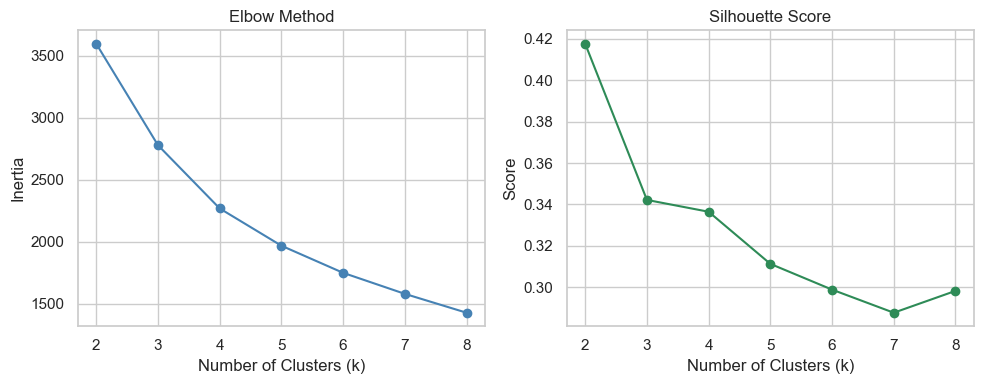

Best k by silhouette: 2 (score=0.418)


In [2]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2)

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='seagreen')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('../data/processed/elbow_silhouette.png', dpi=150)
plt.show()

best_k = k_range.start + silhouettes.index(max(silhouettes))
print(f'Best k by silhouette: {best_k} (score={max(silhouettes):.3f})')

## 4.2 Final Model

In [3]:
# Use best_k from above (adjust manually if elbow plot suggests otherwise)
K = best_k

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

print('Cluster sizes:')
print(rfm['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0     587
1    1422
Name: count, dtype: int64


## 4.3 Interpret Clusters

In [4]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Size'] = rfm['Cluster'].value_counts().sort_index()
print(cluster_summary)

         Recency  Frequency  Monetary  Size
Cluster                                    
0           46.2        3.8     126.8   587
1          150.3        1.2      21.3  1422


In [5]:
# Label clusters based on RFM means
def label_cluster(row):
    if row['Recency'] < cluster_summary['Recency'].median() and row['Monetary'] > cluster_summary['Monetary'].median():
        return 'Champions'
    elif row['Recency'] < cluster_summary['Recency'].median():
        return 'Loyal Customers'
    elif row['Monetary'] > cluster_summary['Monetary'].median():
        return 'At-Risk High Value'
    else:
        return 'Lost / Low Engagement'

cluster_summary['Label'] = cluster_summary.apply(label_cluster, axis=1)
print(cluster_summary)

         Recency  Frequency  Monetary  Size                  Label
Cluster                                                           
0           46.2        3.8     126.8   587              Champions
1          150.3        1.2      21.3  1422  Lost / Low Engagement


## 4.4 Visualize Clusters

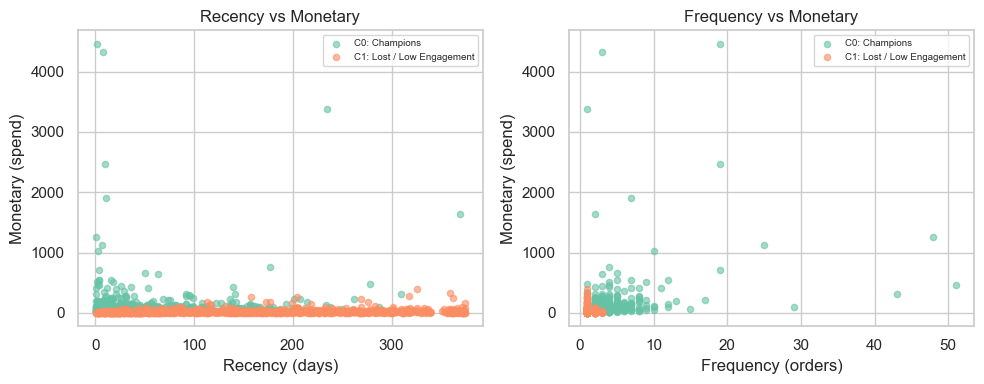

In [6]:
# Scatter: Recency vs Monetary, colored by cluster
palette = sns.color_palette('Set2', K)
fig, axes = plt.subplots(1, 2)

for cluster_id in range(K):
    subset = rfm[rfm['Cluster'] == cluster_id]
    label = cluster_summary.loc[cluster_id, 'Label']
    axes[0].scatter(subset['Recency'], subset['Monetary'],
                    label=f'C{cluster_id}: {label}', alpha=0.6, s=20, color=palette[cluster_id])
    axes[1].scatter(subset['Frequency'], subset['Monetary'],
                    label=f'C{cluster_id}: {label}', alpha=0.6, s=20, color=palette[cluster_id])

axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (spend)')
axes[0].set_title('Recency vs Monetary')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (spend)')
axes[1].set_title('Frequency vs Monetary')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('../data/processed/cluster_scatter.png', dpi=150)
plt.show()

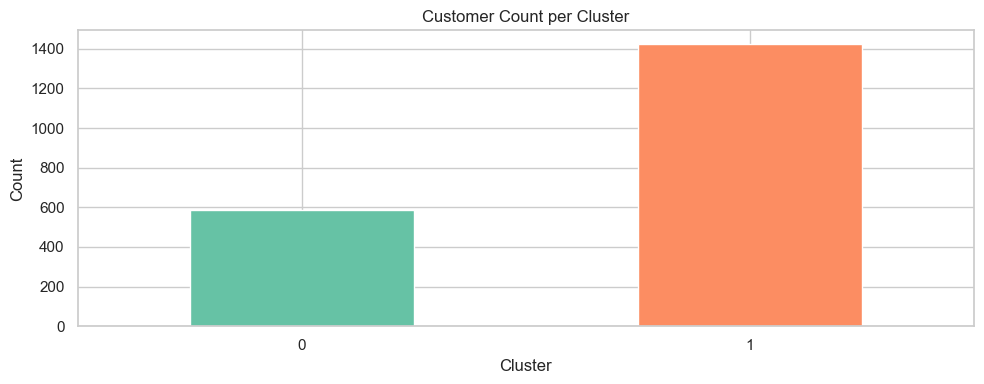

In [7]:
# Bar: cluster size
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color=palette)
plt.title('Customer Count per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/cluster_sizes.png', dpi=150)
plt.show()

## 4.5 Save

In [8]:
rfm.to_csv('../data/processed/rfm_clustered.csv', index=False)
cluster_summary.to_csv('../data/processed/cluster_summary.csv')
print('Saved rfm_clustered.csv and cluster_summary.csv')

Saved rfm_clustered.csv and cluster_summary.csv
